# Moving-Boundary Simulation: Silicate Ceramic Families

This notebook compares Wollastonite (CaSiO3), Diopside (CaMgSi2O6), and an apatite-wollastonite glass-ceramic using the repository's one-dimensional moving-boundary forward solver. The integration spans 28 days and records concentration, porosity, and gel-layer histories.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from kineticai import simulate_moving_boundary_1d

plt.rcParams.update({'figure.figsize': (10, 5), 'font.size': 10})

## Material parameterization

The values below are normalized model parameters for comparative trajectory analysis. The chemistry enters through the Arrhenius-like reactivity `alpha`, while `k_diss` and `source_scale` control the source envelope.

In [2]:
materials = {
    'Wollastonite (CaSiO3)': {'alpha': 0.55, 'k_diss': 0.020, 'source_scale': 0.0010, 'color': '#a91d33'},
    'Diopside (CaMgSi2O6)': {'alpha': 0.28, 'k_diss': 0.014, 'source_scale': 0.0006, 'color': '#1d7a6d'},
    'A-W glass-ceramic': {'alpha': 0.38, 'k_diss': 0.016, 'source_scale': 0.0008, 'color': '#1f5aa8'},
}

results = {}
for name, params in materials.items():
    results[name] = simulate_moving_boundary_1d(
        length=1.0, nx=96, tmax=28.0, dt=0.05, porosity_initial=0.22,
        diffusivity=0.004, convection=0.002,
        alpha=params['alpha'], k_diss=params['k_diss'], source_scale=params['source_scale']
    )

time = results[next(iter(results))]['time_grid']
print(f'Integrated {time[-1]:.1f} days with {len(time)} saved states.')

Integrated 28.0 days with 561 saved states.


## Concentration fields and evolving geometry

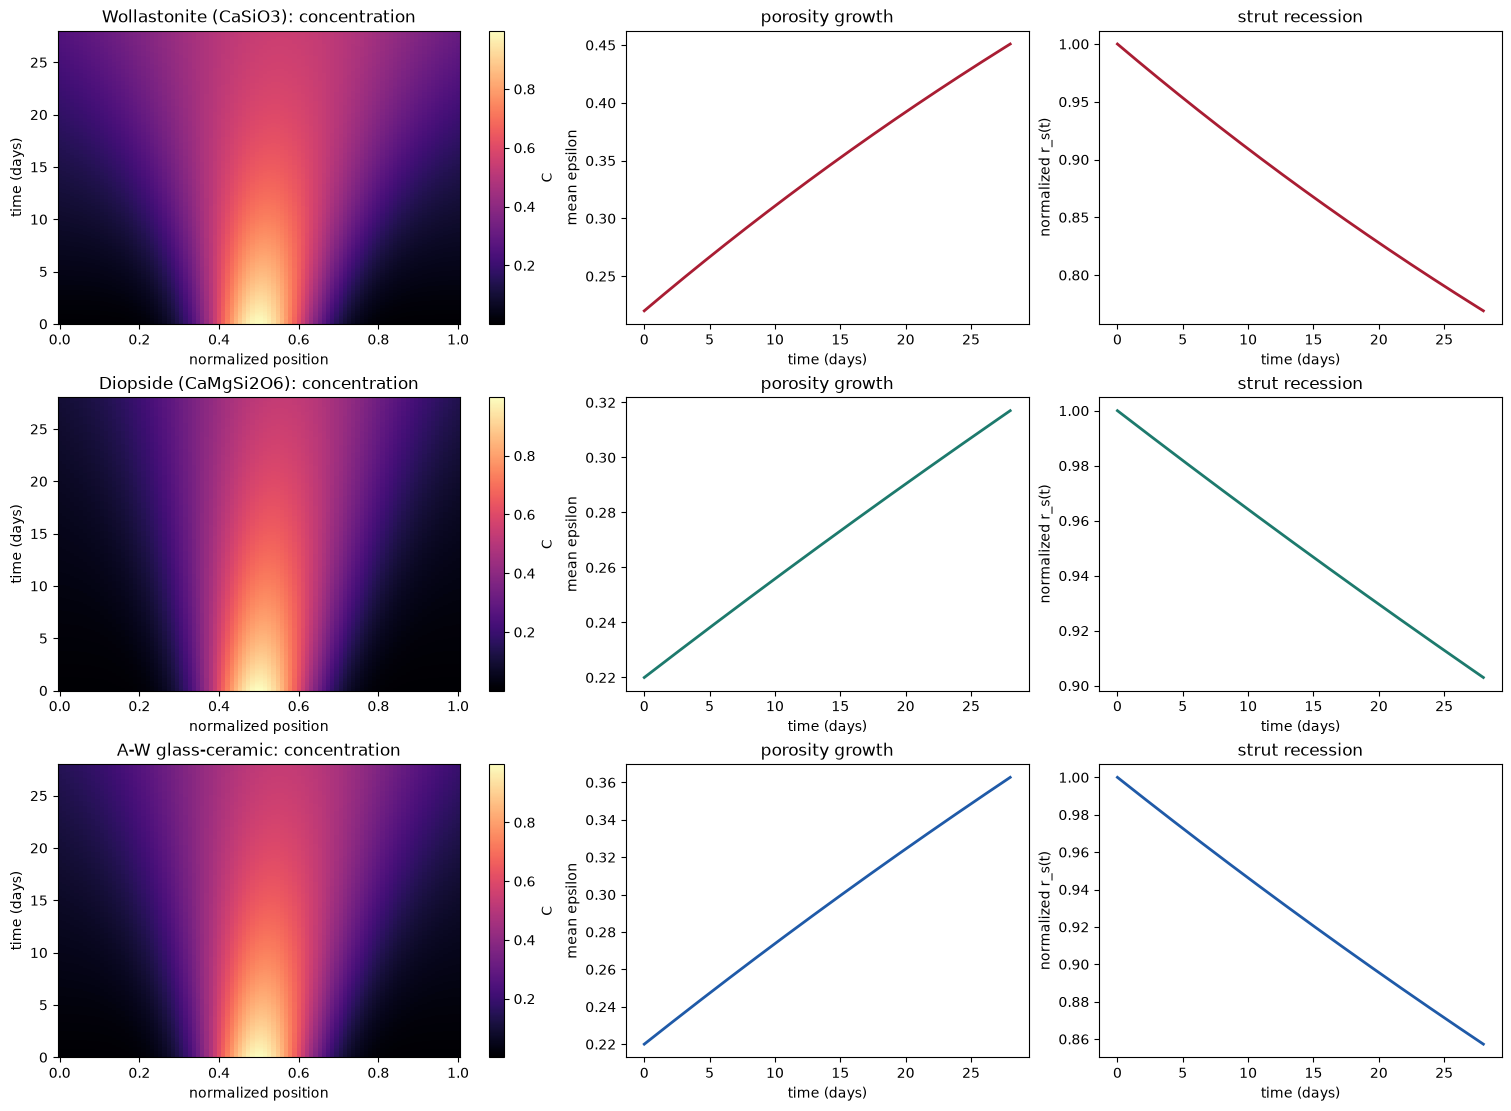

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11), constrained_layout=True)
for row, (name, result) in enumerate(results.items()):
    color = materials[name]['color']
    im = axes[row, 0].pcolormesh(result['x'], result['time_grid'], result['concentration_history'], shading='auto', cmap='magma')
    axes[row, 0].set_title(f'{name}: concentration')
    axes[row, 0].set_ylabel('time (days)')
    axes[row, 0].set_xlabel('normalized position')
    fig.colorbar(im, ax=axes[row, 0], label='C')
    axes[row, 1].plot(result['time_grid'], result['porosity_history'].mean(axis=1), color=color, linewidth=2)
    axes[row, 1].set_title('porosity growth')
    axes[row, 1].set_xlabel('time (days)')
    axes[row, 1].set_ylabel('mean epsilon')
    radius = 1.0 - result['gel_thickness_history'].mean(axis=1)
    axes[row, 2].plot(result['time_grid'], radius, color=color, linewidth=2)
    axes[row, 2].set_title('strut recession')
    axes[row, 2].set_xlabel('time (days)')
    axes[row, 2].set_ylabel('normalized r_s(t)')
plt.show()

## Interpretation

The comparative fields expose the chemistry--architecture coupling: higher effective reactivity produces faster source accumulation, faster porosity growth, and earlier strut recession. The solver history is returned explicitly so these trajectories can be compared with phase-specific biological admissibility bounds.